# Relatorio de Modelagem

**Universidade Estadual de Montes Claros**  
**Especialização em Ciência de Dados**  
**Disciplina:** Projeto Integrado em Ciência de Dados  
**Docente:** Dra. Luciana Balieiro Cosme  
**Alunos:**
*  Luan Silva Gomes
*  Mateus Nobre Silva Almeida
*  Paulo Matheus Mendes  

**Projeto:** Predizer o desempenho em Língua Portuguesa e Matemática, do 5º e 9º ano do Ensino Fundamental, das escolas Estaduais e Municipais do estado de Minas Gerais, utilizando a série histórica de 2015-2025 disponível no Portal das Avaliações Educacionais de Minas Gerais, para que Instituições e pessoas interessadas possam tomar medidas e criar políticas com maior eficiência a fim de melhorar esses indicadores.

## Decisão de modelagem

A variável alvo original da base de dados é `% acerto`. Após tratamento de dados, essa variável foi renomeada para `acerto`.

As métricas principais serão:

- `MAE`: erro absoluto médio, em pontos percentuais de acerto;
- `RMSE`: penaliza mais erros grandes;
- `R²`: proporção aproximada da variabilidade explicada pelo modelo.

## Importação de dependências e configurações iniciais

In [ ]:
from pathlib import Path
import os
import sys
import warnings

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 120)
RANDOM_STATE = 42
TARGET = "acerto"

In [5]:
cwd = Path.cwd().resolve()
if (cwd / "src").exists():
    PROJECT_ROOT = cwd
elif len(cwd.parents) >= 2 and (cwd.parents[1] / "src").exists():
    PROJECT_ROOT = cwd.parents[1]
else:
    PROJECT_ROOT = cwd

sys.path.insert(0, str(PROJECT_ROOT))

from src.simave_preprocessing import (
    find_descriptor_files,
    filter_etapas,
    filter_valid_target,
    load_descriptor_files,
    summarize_target_status,
)

DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"

print(f"Projeto: {PROJECT_ROOT}")
print(f"Diretório de dados brutos: {DATA_RAW_DIR}")

Projeto: /Users/luangomes/Code/projeto-integrado-simave-mg
Diretório de dados brutos: /Users/luangomes/Code/projeto-integrado-simave-mg/data/raw


## Importação e preparação dos dados

In [6]:
files = find_descriptor_files(DATA_RAW_DIR)

if not files:
    raise FileNotFoundError(
        "Nenhum CSV encontrado. Coloque os arquivos em data/raw/ ou ajuste SAMPLE_CSV."
    )

df_raw = load_descriptor_files(files)
print(f"Arquivos carregados: {len(files)}")
print(f"Linhas e colunas após limpeza básica: {df_raw.shape}")
display(pd.DataFrame({"arquivo": [str(file) for file in files[:20]]}))
display(df_raw.head())

Arquivos carregados: 14
Linhas e colunas após limpeza básica: (5569725, 25)


,arquivo
0,/Users/luangomes/Code/projeto-integrado-simave-mg/data/raw/DESCRITORES-2015-ESCOLA-REDE-ESTADUAL.csv
1,/Users/luangomes/Code/projeto-integrado-simave-mg/data/raw/DESCRITORES-2015-ESCOLA-REDE-MUNICIAPAL.csv
2,/Users/luangomes/Code/projeto-integrado-simave-mg/data/raw/DESCRITORES-2016-ESCOLA-REDE-ESTADUAL.csv
3,/Users/luangomes/Code/projeto-integrado-simave-mg/data/raw/DESCRITORES-2016-ESCOLA-REDE-MUNICIAPAL.csv
4,/Users/luangomes/Code/projeto-integrado-simave-mg/data/raw/DESCRITORES-2017-ESCOLA-REDE-MUNICIAPAL.csv
5,/Users/luangomes/Code/projeto-integrado-simave-mg/data/raw/DESCRITORES-2019-ESCOLA-REDE-ESTADUAL.csv
6,/Users/luangomes/Code/projeto-integrado-simave-mg/data/raw/DESCRITORES-2019-ESCOLA-REDE-MUNICIAPAL.csv
7,/Users/luangomes/Code/projeto-integrado-simave-mg/data/raw/DESCRITORES-2021-ESCOLA-REDE-ESTADUAL.csv
8,/Users/luangomes/Code/projeto-integrado-simave-mg/data/raw/DESCRITORES-2022-ESCOLA-REDE-ESTADUAL.csv
9,/Users/luangomes/Code/projeto-integrado-simave-mg/data/raw/DESCRITORES-2022-ESCOLA-REDE-MUNICIAPAL.csv


,tipo,codigo_regional,regional,codigo_municipio,municipio,codigo_escola,escola,edicao,rede,codigo_etapa,etapa,disciplina,descritor_nome,descritor_descricao,acerto,tipo_norm,rede_norm,etapa_norm,disciplina_norm,regional_norm,municipio_norm,is_matematica,is_estadual,acerto_original,acerto_status
0,ESCOLA,1,METROPOLITANA A,3105400,BARAO DE COCAIS,31007692,EE JOSE MARIA DE MORAIS,2015,ESTADUAL,7,7º ANO EF,LINGUA PORTUGUESA,D01,IDENTIFICAR O TEMA OU O SENTIDO GLOBAL DE UM TEXTO,65.0,ESCOLA,ESTADUAL,7O ANO EF,LINGUA PORTUGUESA,METROPOLITANA A,BARAO DE COCAIS,0,1,65,ok
1,ESCOLA,1,METROPOLITANA A,3105400,BARAO DE COCAIS,31007692,EE JOSE MARIA DE MORAIS,2015,ESTADUAL,7,7º ANO EF,LINGUA PORTUGUESA,D02,LOCALIZAR INFORMACOES EXPLICITAS EM UM TEXTO,70.0,ESCOLA,ESTADUAL,7O ANO EF,LINGUA PORTUGUESA,METROPOLITANA A,BARAO DE COCAIS,0,1,70,ok
2,ESCOLA,1,METROPOLITANA A,3105400,BARAO DE COCAIS,31007692,EE JOSE MARIA DE MORAIS,2015,ESTADUAL,7,7º ANO EF,LINGUA PORTUGUESA,D03,INFERIR INFORMACOES EM UM TEXTO,61.0,ESCOLA,ESTADUAL,7O ANO EF,LINGUA PORTUGUESA,METROPOLITANA A,BARAO DE COCAIS,0,1,61,ok
3,ESCOLA,1,METROPOLITANA A,3105400,BARAO DE COCAIS,31007692,EE JOSE MARIA DE MORAIS,2015,ESTADUAL,7,7º ANO EF,LINGUA PORTUGUESA,D04,INFERIR O SENTIDO DE UMA PALAVRA OU EXPRESSAO EM UM TEXTO,64.0,ESCOLA,ESTADUAL,7O ANO EF,LINGUA PORTUGUESA,METROPOLITANA A,BARAO DE COCAIS,0,1,64,ok
4,ESCOLA,1,METROPOLITANA A,3105400,BARAO DE COCAIS,31007692,EE JOSE MARIA DE MORAIS,2015,ESTADUAL,7,7º ANO EF,LINGUA PORTUGUESA,D05,DISTINGUIR UM FATO DE UMA OPINIAO EM UM TEXTO,46.0,ESCOLA,ESTADUAL,7O ANO EF,LINGUA PORTUGUESA,METROPOLITANA A,BARAO DE COCAIS,0,1,46,ok


Registros do 5º e 9º ano do Ensino Fubdamental (EF): 2,350,470


,edicao,rede,etapa,disciplina,acerto_status,registros,percentual
0,2016,ESTADUAL,5º ANO EF,LINGUA PORTUGUESA,baixa_participacao,32,0.10
1,2016,ESTADUAL,5º ANO EF,LINGUA PORTUGUESA,ok,31085,99.84
2,2016,ESTADUAL,5º ANO EF,LINGUA PORTUGUESA,vazio,19,0.06
3,2016,ESTADUAL,5º ANO EF,MATEMATICA,baixa_participacao,52,0.10
4,2016,ESTADUAL,5º ANO EF,MATEMATICA,ok,50463,99.74
5,2016,ESTADUAL,5º ANO EF,MATEMATICA,vazio,81,0.16
6,2016,ESTADUAL,9º ANO EF,LINGUA PORTUGUESA,baixa_participacao,575,0.90
7,2016,ESTADUAL,9º ANO EF,LINGUA PORTUGUESA,ok,63020,99.10
8,2016,ESTADUAL,9º ANO EF,MATEMATICA,baixa_participacao,1025,0.90
9,2016,ESTADUAL,9º ANO EF,MATEMATICA,ok,112311,99.07


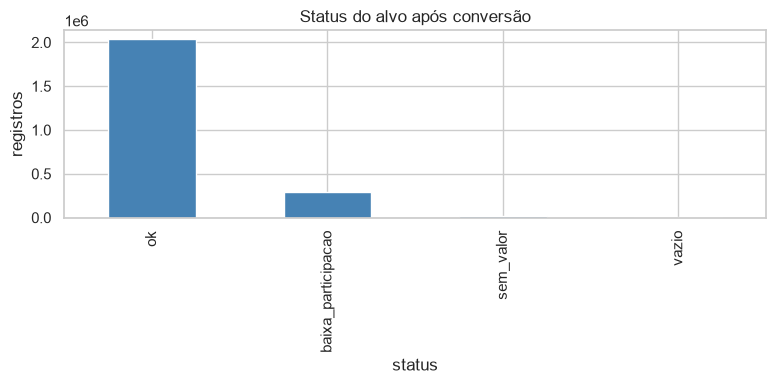

In [7]:
df_59 = filter_etapas(df_raw, etapas=(5, 9))
status_alvo = summarize_target_status(df_59)

print(f"Registros do 5º e 9º ano do Ensino Fubdamental (EF): {df_59.shape[0]:,}")
display(status_alvo.head(20))

fig, ax = plt.subplots(figsize=(8, 4))
df_59["acerto_status"].value_counts().plot.bar(ax=ax, color="steelblue")
ax.set_title("Status do alvo após conversão")
ax.set_xlabel("status")
ax.set_ylabel("registros")
plt.tight_layout()
plt.show()

In [8]:
df_model = filter_valid_target(df_59, target=TARGET).copy()
removidos = len(df_59) - len(df_model)

print(f"Registros com target válido: {len(df_model):,}")
print(f"Registros removidos por target inválido: {removidos:,} ({removidos / len(df_59):.2%})")
display(df_model[TARGET].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(2).to_frame())
display(
    df_model.groupby(["etapa", "disciplina"])[TARGET]
    .agg(registros="size", media="mean", mediana="median", desvio_padrao="std")
    .round(2)
)

Registros com target válido: 2,033,790
Registros removidos por target inválido: 316,680 (13.47%)


,acerto
count,2033790.0
mean,54.31
std,21.71
min,0.0
1%,0.0
5%,19.0
25%,40.0
50%,55.0
75%,69.0
95%,91.0


registros  media  mediana  desvio_padrao
etapa     disciplina                                                 
5º ANO EF LINGUA PORTUGUESA     405140  58.78     60.0          19.14
          MATEMATICA            664163  56.84     58.0           24.4
9º ANO EF LINGUA PORTUGUESA     365510   59.3     60.0          15.12
          MATEMATICA            598977  45.42     43.0          20.92

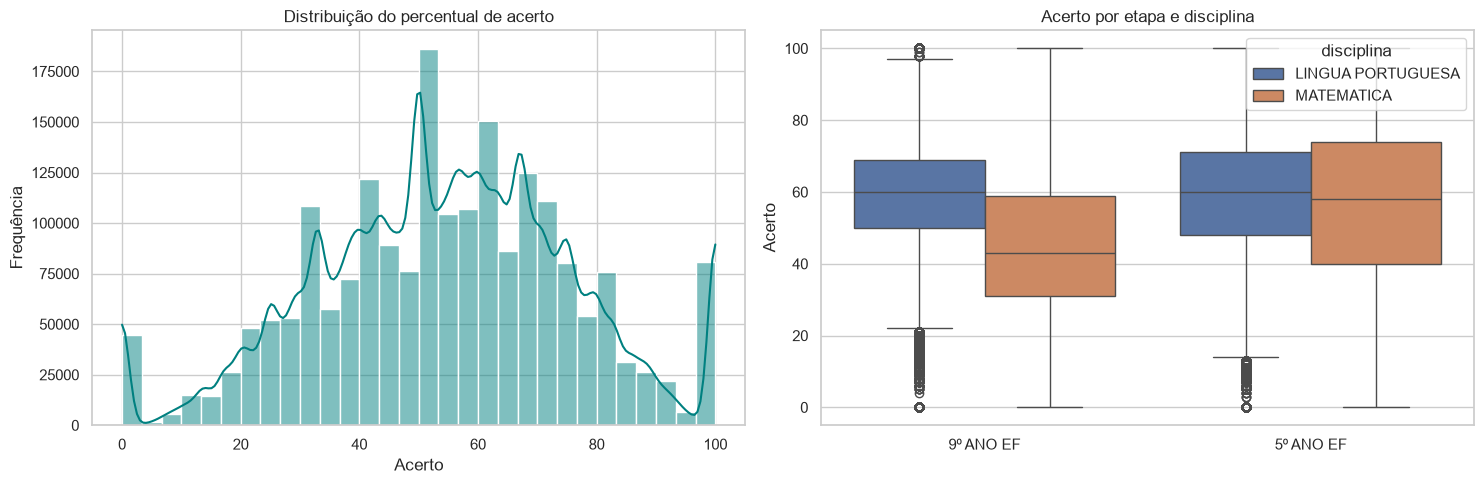

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data=df_model, x=TARGET, bins=30, kde=True, color="teal", ax=axes[0])
axes[0].set_title("Distribuição do percentual de acerto")
axes[0].set_xlabel("Acerto")
axes[0].set_ylabel("Frequência")

sns.boxplot(data=df_model, x="etapa", y=TARGET, hue="disciplina", ax=axes[1])
axes[1].set_title("Acerto por etapa e disciplina")
axes[1].set_xlabel("")
axes[1].set_ylabel("Acerto")

plt.tight_layout()
plt.show()

## Split de treino e teste

Como o projeto usa série histórica, o ideal é testar no ano mais recente e treinar nos anos anteriores.

In [10]:
FEATURES_SEM_ESCOLA = [
    "edicao",
    "rede",
    "etapa",
    "disciplina",
    "regional",
    "municipio",
    "descritor_nome",
]
FEATURES_COM_ESCOLA = FEATURES_SEM_ESCOLA + ["codigo_escola"]

FEATURES_SEM_ESCOLA = [column for column in FEATURES_SEM_ESCOLA if column in df_model.columns]
FEATURES_COM_ESCOLA = [column for column in FEATURES_COM_ESCOLA if column in df_model.columns]

df_model = df_model.sort_values(["edicao", "codigo_escola", "disciplina", "descritor_nome"]).reset_index(drop=True)
anos = sorted(df_model["edicao"].dropna().unique())

if len(anos) >= 2:
    test_year = anos[-1]
    train_df = df_model.loc[df_model["edicao"] < test_year].copy()
    test_df = df_model.loc[df_model["edicao"] == test_year].copy()
    split_strategy = f"temporal: treino até {anos[-2]}, teste em {test_year}"
else:
    train_df, test_df = train_test_split(
        df_model,
        test_size=0.30,
        random_state=RANDOM_STATE,
    )
    split_strategy = "aleatório, porque só há um ano disponível"

print(split_strategy)
print(f"Treino: {train_df.shape}")
print(f"Teste: {test_df.shape}")
display(train_df[TARGET].describe().round(2).rename("treino").to_frame())
display(test_df[TARGET].describe().round(2).rename("teste").to_frame())

temporal: treino até 2022, teste em 2023
Treino: (1556599, 25)
Teste: (477191, 25)


,treino
count,1556599.0
mean,55.22
std,21.57
min,0.0
25%,40.0
50%,56.0
75%,70.0
max,100.0


,teste
count,477191.0
mean,51.33
std,21.88
min,0.0
25%,36.0
50%,51.0
75%,67.0
max,100.0


In [11]:
train_years = sorted(train_df["edicao"].dropna().unique())

if len(train_years) >= 3:
    n_splits = min(5, len(train_years))
    cv = GroupKFold(n_splits=n_splits)
    cv_groups = train_df["edicao"]
    cv_strategy = f"GroupKFold por edição, {n_splits} folds"
else:
    n_splits = 5 if len(train_df) >= 5 else len(train_df)
    if n_splits < 2:
        raise ValueError("Não há registros suficientes para validação cruzada.")
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    cv_groups = None
    cv_strategy = f"KFold aleatório, {n_splits} folds"

print(cv_strategy)

GroupKFold por edição, 4 folds


# Seção 1 - Baseline

O baseline usa a regra mais simples possível para regressão: prever sempre a mediana do `acerto` observada no treino.

Ele define o piso. Qualquer modelo útil precisa reduzir MAE e RMSE em relação a essa regra simples.

In [12]:
NUMERIC_FEATURES = ["edicao"]


def split_feature_types(features):
    numeric = [feature for feature in features if feature in NUMERIC_FEATURES]
    categorical = [feature for feature in features if feature not in numeric]
    return numeric, categorical


def make_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)


def build_onehot_pipeline(model, features):
    numeric_features, categorical_features = split_feature_types(features)
    transformers = []

    if numeric_features:
        numeric = Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]
        )
        transformers.append(("numericas", numeric, numeric_features))

    if categorical_features:
        categorical = Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", make_onehot_encoder()),
            ]
        )
        transformers.append(("categoricas", categorical, categorical_features))

    preprocessor = ColumnTransformer(transformers=transformers, remainder="drop")
    return Pipeline(steps=[("preprocess", preprocessor), ("model", model)])


def build_ordinal_pipeline(model, features):
    numeric_features, categorical_features = split_feature_types(features)
    transformers = []

    if numeric_features:
        numeric = Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])
        transformers.append(("numericas", numeric, numeric_features))

    if categorical_features:
        categorical = Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
            ]
        )
        transformers.append(("categoricas", categorical, categorical_features))

    preprocessor = ColumnTransformer(transformers=transformers, remainder="drop")
    return Pipeline(steps=[("preprocess", preprocessor), ("model", model)])


def run_cv(nome, estimator, features, feature_set, hiperparametros, justificativa):
    X = train_df[features]
    y = train_df[TARGET]
    scoring = {
        "mae": "neg_mean_absolute_error",
        "mse": "neg_mean_squared_error",
        "r2": "r2",
    }
    scores = cross_validate(
        estimator,
        X,
        y,
        cv=cv,
        groups=cv_groups,
        scoring=scoring,
        n_jobs=1,
        error_score="raise",
    )

    mae_values = -scores["test_mae"]
    rmse_values = np.sqrt(-scores["test_mse"])
    r2_values = scores["test_r2"]

    return {
        "modelo": nome,
        "feature_set": feature_set,
        "features": features,
        "hiperparametros": hiperparametros,
        "justificativa": justificativa,
        "mae_mean": mae_values.mean(),
        "mae_std": mae_values.std(),
        "rmse_mean": rmse_values.mean(),
        "rmse_std": rmse_values.std(),
        "r2_mean": r2_values.mean(),
        "r2_std": r2_values.std(),
    }


def format_mean_std(row, metric):
    return f"{row[f'{metric}_mean']:.3f} ± {row[f'{metric}_std']:.3f}"

In [13]:
estimators = {}
feature_sets = {}

baseline = build_onehot_pipeline(
    DummyRegressor(strategy="median"),
    FEATURES_SEM_ESCOLA,
)
baseline_result = run_cv(
    nome="Baseline - mediana",
    estimator=baseline,
    features=FEATURES_SEM_ESCOLA,
    feature_set="sem codigo_escola",
    hiperparametros={"strategy": "median"},
    justificativa="Prevê sempre a mediana do acerto no treino; define o piso da regressão.",
)

estimators[baseline_result["modelo"]] = baseline
feature_sets[baseline_result["modelo"]] = FEATURES_SEM_ESCOLA

display(
    pd.DataFrame([baseline_result]).assign(
        mae_cv=lambda data: data.apply(lambda row: format_mean_std(row, "mae"), axis=1),
        rmse_cv=lambda data: data.apply(lambda row: format_mean_std(row, "rmse"), axis=1),
        r2_cv=lambda data: data.apply(lambda row: format_mean_std(row, "r2"), axis=1),
    )[["modelo", "mae_cv", "rmse_cv", "r2_cv", "justificativa"]]
)

,modelo,mae_cv,rmse_cv,r2_cv,justificativa
0,Baseline - mediana,17.033 ± 0.760,21.276 ± 0.966,-0.017 ± 0.013,Prevê sempre a mediana do acerto no treino; define o piso da regressão.


# Seção 2 - Experimentos

Foram testadas três abordagens de regressão:

- um modelo linear regularizado, como referência interpretável;
- uma alternativa linear mais escalável;
- um modelo de boosting, capaz de capturar relações não lineares e interações.

In [14]:
experiment_specs = [
    {
        "nome": "Ridge Regression",
        "builder": build_onehot_pipeline,
        "features": FEATURES_SEM_ESCOLA,
        "feature_set": "sem codigo_escola",
        "model": Ridge(alpha=1.0),
        "hiperparametros": {"alpha": 1.0},
        "justificativa": "Modelo linear regularizado, simples e interpretável para variáveis categóricas codificadas.",
    },
    {
        "nome": "SGDRegressor",
        "builder": build_onehot_pipeline,
        "features": FEATURES_COM_ESCOLA,
        "feature_set": "com codigo_escola",
        "model": SGDRegressor(
            loss="squared_error",
            penalty="l2",
            alpha=0.0001,
            max_iter=1000,
            random_state=RANDOM_STATE,
        ),
        "hiperparametros": {
            "loss": "squared_error",
            "penalty": "l2",
            "alpha": 0.0001,
            "max_iter": 1000,
        },
        "justificativa": "Alternativa linear mais escalável para muitos registros e muitas categorias, incluindo escola.",
    },
    {
        "nome": "HistGradientBoostingRegressor",
        "builder": build_ordinal_pipeline,
        "features": FEATURES_SEM_ESCOLA,
        "feature_set": "sem codigo_escola",
        "model": HistGradientBoostingRegressor(
            learning_rate=0.08,
            max_iter=150,
            max_leaf_nodes=31,
            l2_regularization=0.0,
            random_state=RANDOM_STATE,
        ),
        "hiperparametros": {
            "learning_rate": 0.08,
            "max_iter": 150,
            "max_leaf_nodes": 31,
            "l2_regularization": 0.0,
        },
        "justificativa": "Modelo de árvores que captura interações e relações não lineares entre etapa, disciplina, descritor, rede e território.",
    },
]

experiment_results = []
for spec in experiment_specs:
    estimator = spec["builder"](spec["model"], spec["features"])
    result = run_cv(
        nome=spec["nome"],
        estimator=estimator,
        features=spec["features"],
        feature_set=spec["feature_set"],
        hiperparametros=spec["hiperparametros"],
        justificativa=spec["justificativa"],
    )
    experiment_results.append(result)
    estimators[result["modelo"]] = estimator
    feature_sets[result["modelo"]] = spec["features"]

resultados = pd.DataFrame([baseline_result] + experiment_results)
resultados_formatados = resultados.assign(
    mae_cv=lambda data: data.apply(lambda row: format_mean_std(row, "mae"), axis=1),
    rmse_cv=lambda data: data.apply(lambda row: format_mean_std(row, "rmse"), axis=1),
    r2_cv=lambda data: data.apply(lambda row: format_mean_std(row, "r2"), axis=1),
)

display(
    resultados_formatados[
        [
            "modelo",
            "feature_set",
            "hiperparametros",
            "mae_cv",
            "rmse_cv",
            "r2_cv",
            "justificativa",
        ]
    ]
)

,modelo,feature_set,hiperparametros,mae_cv,rmse_cv,r2_cv,justificativa
0,Baseline - mediana,sem codigo_escola,{'strategy': 'median'},17.033 ± 0.760,21.276 ± 0.966,-0.017 ± 0.013,Prevê sempre a mediana do acerto no treino; define o piso da regressão.
1,Ridge Regression,sem codigo_escola,{'alpha': 1.0},14.739 ± 0.668,18.990 ± 0.708,0.186 ± 0.078,"Modelo linear regularizado, simples e interpretável para variáveis categóricas codificadas."
2,SGDRegressor,com codigo_escola,"{'loss': 'squared_error', 'penalty': 'l2', 'alpha': 0.0001, 'max_iter': 1000}",14.345 ± 0.689,18.598 ± 0.766,0.220 ± 0.070,"Alternativa linear mais escalável para muitos registros e muitas categorias, incluindo escola."
3,HistGradientBoostingRegressor,sem codigo_escola,"{'learning_rate': 0.08, 'max_iter': 150, 'max_leaf_nodes': 31, 'l2_regularization': 0.0}",14.680 ± 1.226,19.013 ± 1.196,0.173 ± 0.175,"Modelo de árvores que captura interações e relações não lineares entre etapa, disciplina, descritor, rede e território."


# Seção 3 - Modelo final

O modelo final é escolhido pelo menor `RMSE` médio na validação cruzada. Em caso de empate prático, a preferência deve ir para o modelo mais simples e estável.

In [15]:
modelos_validos = resultados.loc[resultados["modelo"] != "Baseline - mediana"].copy()
best_row = modelos_validos.sort_values(["rmse_mean", "mae_mean", "r2_mean"], ascending=[True, True, False]).iloc[0]
best_name = best_row["modelo"]
final_model = estimators[best_name]
final_features = feature_sets[best_name]

print(f"Modelo escolhido: {best_name}")
print(f"Feature set: {best_row['feature_set']}")
print(f"Hiperparâmetros: {best_row['hiperparametros']}")
print(f"Justificativa: {best_row['justificativa']}")
print(f"RMSE CV: {format_mean_std(best_row, 'rmse')}")
print(f"MAE CV: {format_mean_std(best_row, 'mae')}")
print(f"R² CV: {format_mean_std(best_row, 'r2')}")

X_train = train_df[final_features]
y_train = train_df[TARGET]
X_test = test_df[final_features]
y_test = test_df[TARGET]

final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)
y_pred = np.clip(y_pred, 0, 100)

Modelo escolhido: SGDRegressor
Feature set: com codigo_escola
Hiperparâmetros: {'loss': 'squared_error', 'penalty': 'l2', 'alpha': 0.0001, 'max_iter': 1000}
Justificativa: Alternativa linear mais escalável para muitos registros e muitas categorias, incluindo escola.
RMSE CV: 18.598 ± 0.766
MAE CV: 14.345 ± 0.689
R² CV: 0.220 ± 0.070


In [16]:
mae_teste = mean_absolute_error(y_test, y_pred)
rmse_teste = np.sqrt(mean_squared_error(y_test, y_pred))
r2_teste = r2_score(y_test, y_pred)

print(f"MAE teste: {mae_teste:.3f}")
print(f"RMSE teste: {rmse_teste:.3f}")
print(f"R² teste: {r2_teste:.3f}")

MAE teste: 14.671
RMSE teste: 19.310
R² teste: 0.221


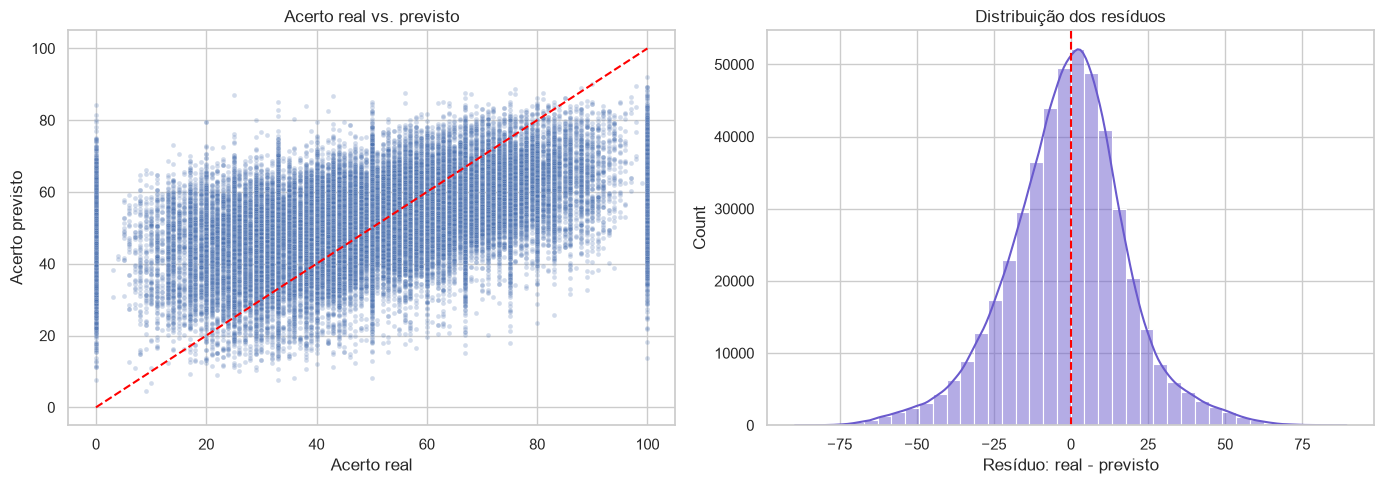

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

amostra_plot = pd.DataFrame({"real": y_test, "previsto": y_pred})
if len(amostra_plot) > 50000:
    amostra_plot = amostra_plot.sample(50000, random_state=RANDOM_STATE)

sns.scatterplot(data=amostra_plot, x="real", y="previsto", alpha=0.25, s=12, ax=axes[0])
axes[0].plot([0, 100], [0, 100], color="red", linestyle="--")
axes[0].set_title("Acerto real vs. previsto")
axes[0].set_xlabel("Acerto real")
axes[0].set_ylabel("Acerto previsto")

residuos = y_test.to_numpy() - y_pred
sns.histplot(residuos, bins=40, kde=True, color="slateblue", ax=axes[1])
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("Distribuição dos resíduos")
axes[1].set_xlabel("Resíduo: real - previsto")

plt.tight_layout()
plt.show()

# Seção 4 - Análise de erros

Na regressão, erro não é falso positivo ou falso negativo. Aqui avaliamos:

- erro absoluto: o quanto a previsão ficou distante do valor real;
- resíduo: `real - previsto`;
- subestimação: resíduo positivo, quando o modelo previu abaixo do observado;
- superestimação: resíduo negativo, quando o modelo previu acima do observado.

In [18]:
predicoes = test_df.copy()
predicoes["acerto_real"] = y_test.to_numpy()
predicoes["acerto_previsto"] = y_pred
predicoes["residuo"] = predicoes["acerto_real"] - predicoes["acerto_previsto"]
predicoes["erro_absoluto"] = predicoes["residuo"].abs()
predicoes["tipo_erro"] = np.select(
    [
        predicoes["residuo"] > 0,
        predicoes["residuo"] < 0,
    ],
    [
        "subestimou_desempenho",
        "superestimou_desempenho",
    ],
    default="exato",
)

display(predicoes[["acerto_real", "acerto_previsto", "residuo", "erro_absoluto", "tipo_erro"]].describe().round(3))
display(predicoes["tipo_erro"].value_counts().rename("registros").to_frame())

,acerto_real,acerto_previsto,residuo,erro_absoluto
count,477191.000,477191.000,477191.000,477191.000
mean,51.332,52.581,-1.250,14.671
std,21.880,11.703,19.269,12.555
min,0.000,2.480,-89.467,0.000
25%,36.000,45.232,-12.554,5.274
50%,51.000,53.143,-0.391,11.368
75%,67.000,60.786,10.358,20.429
max,100.000,99.097,89.322,89.467


,registros
tipo_erro,
superestimou_desempenho,243062
subestimou_desempenho,234129


In [19]:
def resumo_erros_por(coluna, min_registros=30):
    resumo = (
        predicoes.groupby(coluna, dropna=False)
        .agg(
            registros=("erro_absoluto", "size"),
            mae=("erro_absoluto", "mean"),
            mediana_erro_abs=("erro_absoluto", "median"),
            residuo_medio=("residuo", "mean"),
            acerto_real_medio=("acerto_real", "mean"),
            acerto_previsto_medio=("acerto_previsto", "mean"),
        )
        .reset_index()
    )
    resumo = resumo.loc[resumo["registros"] >= min_registros].copy()
    return resumo.sort_values(["mae", "registros"], ascending=[False, False])


for coluna in ["etapa", "disciplina", "rede", "regional", "descritor_nome"]:
    if coluna in predicoes.columns:
        print(f"\nErros por {coluna}")
        display(resumo_erros_por(coluna).head(10).round(3))


Erros por etapa


,etapa,registros,mae,mediana_erro_abs,residuo_medio,acerto_real_medio,acerto_previsto_medio
0,5º ANO EF,244391,15.003,11.228,-1.381,54.671,56.052
1,9º ANO EF,232800,14.322,11.511,-1.111,47.826,48.938



Erros por disciplina


,disciplina,registros,mae,mediana_erro_abs,residuo_medio,acerto_real_medio,acerto_previsto_medio
1,MATEMATICA,306301,16.036,12.696,-4.035,46.464,50.498
0,LINGUA PORTUGUESA,170890,12.224,9.494,3.743,60.057,56.315



Erros por rede


,rede,registros,mae,mediana_erro_abs,residuo_medio,acerto_real_medio,acerto_previsto_medio
1,MUNICIPAL,263236,15.640,11.810,-1.492,52.383,53.875
0,ESTADUAL,213955,13.479,10.862,-0.951,50.038,50.989



Erros por regional


,regional,registros,mae,mediana_erro_abs,residuo_medio,acerto_real_medio,acerto_previsto_medio
1,SRE ARACUAI,13517,18.673,14.440,-0.974,49.156,50.130
10,SRE DIAMANTINA,14951,17.961,13.761,-0.005,52.637,52.641
13,SRE GUANHAES,9900,17.597,13.831,0.490,52.195,51.705
20,SRE MANHUACU,12724,17.453,13.727,-2.507,52.190,54.697
17,SRE JANUARIA,18501,17.340,13.508,-1.472,44.313,45.785
0,SRE ALMENARA,8752,16.940,12.739,0.042,47.006,46.964
12,SRE GOVERNADOR VALADARES,17287,16.478,12.539,0.137,52.107,51.970
5,SRE CARATINGA,11263,16.459,12.792,-0.358,56.171,56.529
25,SRE MONTES CLAROS,22154,16.383,12.461,-0.621,50.093,50.713
41,SRE TEOFILO OTONI,20434,16.336,12.440,-1.252,45.637,46.889



Erros por descritor_nome


,descritor_nome,registros,mae,mediana_erro_abs,residuo_medio,acerto_real_medio,acerto_previsto_medio
37,D32_SAEB,3530,23.931,23.492,-22.411,27.590,50.001
28,D25,5440,23.086,20.965,-17.076,46.711,63.787
32,D27_SAEB,3524,23.023,22.676,-21.217,28.790,50.007
41,D35_SAEB,3505,22.237,20.580,-17.443,32.573,50.017
22,D21,3532,21.181,21.044,20.410,69.374,48.964
25,D23_SAEB,9028,19.609,17.020,-3.409,46.910,50.319
48,D45,5434,19.251,15.660,12.128,59.073,46.945
31,D27,5530,18.729,16.569,-13.277,29.755,43.033
19,D19_SAEB,3528,18.643,17.295,16.497,66.504,50.007
30,D26,5434,18.410,14.687,-6.384,59.114,65.498


In [20]:
piores_erros = predicoes.sort_values("erro_absoluto", ascending=False)
display(
    piores_erros[
        [
            "edicao",
            "rede",
            "etapa",
            "disciplina",
            "regional",
            "municipio",
            "codigo_escola",
            "descritor_nome",
            "acerto_real",
            "acerto_previsto",
            "residuo",
            "erro_absoluto",
        ]
    ].head(20)
)

,edicao,rede,etapa,disciplina,regional,municipio,codigo_escola,descritor_nome,acerto_real,acerto_previsto,residuo,erro_absoluto
1892362,2023,MUNICIPAL,5º ANO EF,MATEMATICA,SRE CONSELHEIRO LAFAIETE,LAMIM,31195464,D82,0.0,89.466728,-89.466728,89.466728
1829416,2023,MUNICIPAL,9º ANO EF,MATEMATICA,SRE TEOFILO OTONI,OURO VERDE DE MINAS,31155543,D61,100.0,10.678448,89.321552,89.321552
1791922,2023,MUNICIPAL,5º ANO EF,MATEMATICA,SRE PONTE NOVA,PORTO FIRME,31132080,D82,0.0,88.652431,-88.652431,88.652431
1698713,2023,MUNICIPAL,5º ANO EF,MATEMATICA,SRE MANHUACU,MUTUM,31075566,D83,0.0,87.934750,-87.934750,87.934750
1975664,2023,MUNICIPAL,9º ANO EF,MATEMATICA,SRE JANUARIA,CONEGO MARINHO,31273741,D64,100.0,12.697431,87.302569,87.302569
1912930,2023,MUNICIPAL,9º ANO EF,MATEMATICA,SRE MONTES CLAROS,CORACAO DE JESUS,31216399,D64,100.0,13.091931,86.908069,86.908069
1890237,2023,MUNICIPAL,5º ANO EF,MATEMATICA,SRE CONSELHEIRO LAFAIETE,LAMIM,31194093,D82,0.0,86.399075,-86.399075,86.399075
1943414,2023,ESTADUAL,9º ANO EF,MATEMATICA,SRE JANUARIA,JANUARIA,31246280,D64,100.0,13.688310,86.311690,86.311690
1766076,2023,MUNICIPAL,9º ANO EF,MATEMATICA,SRE UNAI,URUANA DE MINAS,31114111,D64,100.0,14.305576,85.694424,85.694424
1600638,2023,ESTADUAL,5º ANO EF,LINGUA PORTUGUESA,SRE CARATINGA,BOM JESUS DO GALHO,31019135,D19,0.0,84.897084,-84.897084,84.897084


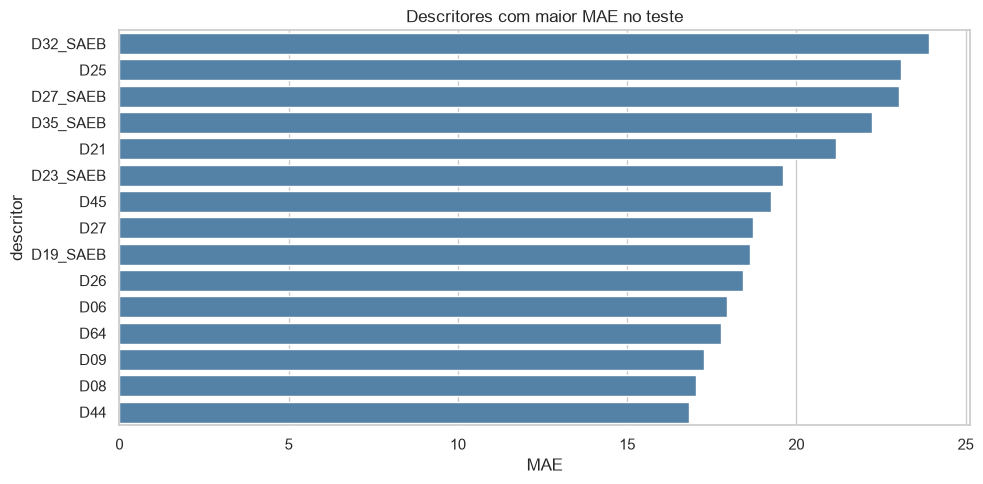

In [21]:
if "descritor_nome" in predicoes.columns:
    top_descritores = resumo_erros_por("descritor_nome").head(15)
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=top_descritores, x="mae", y="descritor_nome", color="steelblue", ax=ax)
    ax.set_title("Descritores com maior MAE no teste")
    ax.set_xlabel("MAE")
    ax.set_ylabel("descritor")
    plt.tight_layout()
    plt.show()